In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
import matplotlib.colors as mcolors
import pandas as pd
import seaborn as sns
from scipy.special import softmax

import utilities as utils

### Script parameters and variables

In [2]:
### operational parameters ###

savedir = "./Figures/"
savefigflag = False
savedataflag = True # save data produced by this notebook
loaddataflag = True # load data already produced by this notebook, instead of re-running analyses

beads_datadir = "./Data/beads/"
horses_datadir = "./Data/horses/"

# number of threads for parallelized analyses
N_threads = 22


### parameters governing analyses ###

# confidence interval of I(R;Y) for bootstrapping analyses
CI = (2.5, 97.5)
boot_iters = 1000 # number of bootstrap iterations

# number of beads to include in X, from current trial backward (bead-prediction experiment) for "fully-optimal" strategy
wsize = 7

# limit for the number of iterations for the IB algorithm
IB_iterlimit = 100000
N_b_ib = 1000 # number of beta points to sample for the standard IB algorithm
max_b_ib = 50 # maximum beta value to sample for the standard IB algorithm
N_b_softmax = 10000 # number of betastar points to sample for the softmax solution
max_b_softmax = 50 # maximum betastar value to sample for the softmax solution


### fixed parameters for the generative structure of the experiments ###

# generative parameters for the bead-prediction experiment
h_=0.99 # jar stay probability
p0_=0.8 # probability of drawing bead type 0 from jar 0
p1_=0.2 # probability of drawing bead type 0 from jar 1
P0 = np.array([[0.5],[0.5]]) # prior over jars for computing posterior probabilities over hidden markov process
H = np.ones((2,2)) - np.abs(np.eye(2)*-1 + h_) # transition matrix
E = np.vstack((np.array([[1,0]])*p0_ + np.array([[0,1]])*(1-p0_),np.array([[1,0]])*p1_ + np.array([[0,1]])*(1-p1_))) # emission matrix

# generative parameters for the horse prediction experiments
paramdict = {
    'lowWS': {
        'weakLLR': 0.45,
        'WSratio': 1.3,
        'p1': 0.06
    },
    'midWS': {
        'weakLLR': 0.2,
        'WSratio': 2.5,
        'p1': 0.08
    },
    'highWS': {
        'weakLLR': 0.18,
        'WSratio': 6.3,
        'p1': 0.02
    }
}

# p(Y) for both tasks
p_Y = np.array([[0.5, 0.5]])


### plotting parameters ###

# teal color map
start_color = "#ffffff"  
end_color = "#136666"    
cmap_t = mcolors.LinearSegmentedColormap.from_list("custom_cmap", [start_color, end_color])

# red color map
cmap_r = matplotlib.colormaps.get_cmap('Reds')

optcolor = "#298C8C"
heurcolor = "#A00000"
nonecolor = 'orange'


### helper functions ###

def savefig(fig, name, ftype="svg", savefigflag=savefigflag, savedir=savedir):
    if savefigflag:
        fig.savefig(savedir + name + "." + ftype, bbox_inches="tight", dpi=300)

def format_axis(ax):
    ax.tick_params(axis='x', labelsize=5, width=0.5, length=2)
    ax.tick_params(axis='y', labelsize=5, width=0.5, length=2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)

def get_color(index,values,vmin,vmax):
    return np.clip(1-(values[index]-vmin)/(vmax-vmin),0,1)

### Import some preprocessed data

In [26]:
# bead prediction trial sequence
beads_trial_seq = pd.read_csv(beads_datadir + "trial_sequence.csv")
jars_emp_raw = beads_trial_seq['jar'].to_numpy()
beads_emp_raw = beads_trial_seq['bead'].to_numpy()
beads_emp, jars_emp = utils.getXY_beads(beads_emp_raw, jars_emp_raw, wsize)

# horse prediction experiment trial sets (emp = empirical data)
lowWS_trial_set = pd.read_csv(horses_datadir + "lowWS/trial_set.csv")
shapes_low_emp = utils.split_to_four_digits(lowWS_trial_set['observation_encoding'].to_numpy())
horses_low_emp = lowWS_trial_set['latent_state'].to_numpy()

midWS_trial_set = pd.read_csv(horses_datadir + "midWS_learning/trial_set.csv")
shapes_mid_emp = utils.split_to_four_digits(midWS_trial_set['observation_encoding'].to_numpy())
horses_mid_emp = midWS_trial_set['latent_state'].to_numpy()

highWS_trial_set = pd.read_csv(horses_datadir + "highWS/trial_set.csv")
shapes_high_emp = utils.split_to_four_digits(highWS_trial_set['observation_encoding'].to_numpy())
horses_high_emp = highWS_trial_set['latent_state'].to_numpy()

shapes_emp_dict = {
    'lowWS': shapes_low_emp,
    'midWS': shapes_mid_emp,
    'highWS': shapes_high_emp
}

horses_emp_dict = {
    'lowWS': horses_low_emp,
    'midWS': horses_mid_emp,
    'highWS': horses_high_emp
}

## Figure 1
Visual assets for task overviews

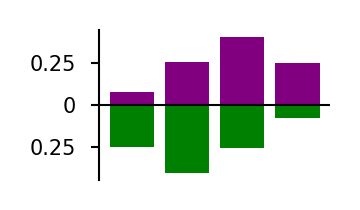

In [4]:
weakLLR = paramdict['midWS']['weakLLR']
WSratio = paramdict['midWS']['WSratio']
pdist1, pdist2 = utils.llr2probs_4shapes(llr=np.array([-weakLLR*WSratio, -weakLLR, weakLLR, weakLLR*WSratio]), p1=paramdict['midWS']['p1'])

fig, ax = plt.subplots(figsize=(1.3,0.8), dpi=300)

ax.bar(np.arange(4), pdist1, color='purple', label='state 1')

ax.bar(np.arange(4), -pdist2, color='green', label='state 2')
xlims = ax.get_xlim()
ax.plot(xlims, [0,0], color='black', linewidth=0.5)
ax.set_xlim(xlims)
ax.axes.get_xaxis().set_visible(False)
ax.set_yticks([-0.25, 0, 0.25])
ax.set_yticklabels(['0.25','0','0.25'])

format_axis(ax)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
savefig(fig, 'Figure1/figure1_likelihoods')
# plt.savefig(savedir+'Figure1/figure1_likelihoods.svg', bbox_inches='tight')

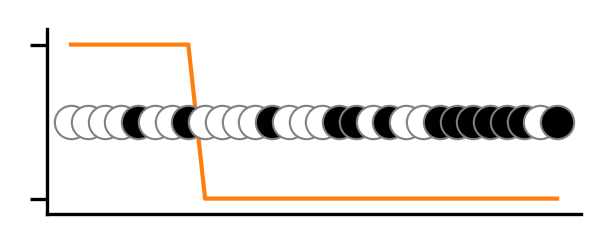

In [5]:
mfcs = {
    0: 'black',
    1: 'white'
}

mecs = {
    1: 'gray',
    0: 'gray'
}

cmap = plt.get_cmap("tab10")

fig = plt.figure(figsize=(2.3,0.8), dpi=300)
ax = fig.add_subplot(111)

ax.plot(jars_emp[55:85],c=cmap(1),linewidth=1)
for tt in range(55,85):
    ax.plot(tt-55,0.5,'o',markersize=8,markeredgewidth=0.5,mec=mecs[beads_emp_raw[tt]],mfc=mfcs[beads_emp_raw[tt]])
ax.set_ylim([-0.1,1.1])
ax.set_xticks([])
ax.set_yticks([0,1],labels=[])

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.8)

ax.tick_params(axis='x', labelsize=5, width=0.8, length=4)
ax.tick_params(axis='y', labelsize=5, width=0.8, length=4)
sns.despine()
# ax.spines['bottom'].set_linewidth(0.5)
# ax.spines['left'].set_linewidth(0.5)
savefig(fig, 'Figure1/figure1_bead_seq')

## Figure 2
Basic IB theoretical results and visual assets for the figure

In [6]:
# get IB bound (IB-optimal for true p(X,Y)) on the experimental trial set
shapes_Xset = utils.get_shapes_Xset()
p_XgY = utils.P_shapecomb_g_horse(shapes_Xset,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'])
emp_bound = utils.get_IB_bound_emp(shapes_high_emp,shapes_Xset,horses_high_emp,p_XgY,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads)

# get IB curve for softmax solution on the experimental trial set
p_YgX_emp = utils.P_horse_g_shapecomb(shapes_high_emp,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'],p_Y=p_Y)
emp_softmax_curve = utils.get_softmax_IB_curve_emp(shapes_high_emp,horses_high_emp,p_YgX_emp,N_b=N_b_softmax,max_b=max_b_softmax)

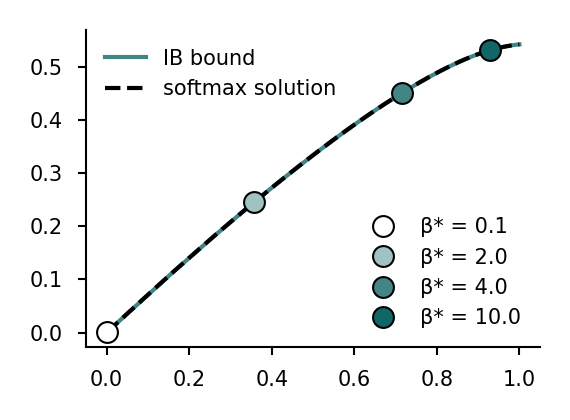

In [7]:
betastars = np.array([0.1, 2, 4, 10])

fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

ibbound, = ax.plot(emp_bound['I_XR'], emp_bound['I_RY'], label='IB bound', color=cmap_t(0.8), linewidth=1)
softmaxbound, = ax.plot(emp_softmax_curve['I_XR'], emp_softmax_curve['I_RY'], '--k',linewidth=1, label='softmax solution')

legend_handles = []
legend_labels = []
for ii, bb in enumerate(betastars):
    softmax_soln = utils.get_softmax_IB_emp(bb,shapes_high_emp,horses_high_emp,p_YgX_emp,return_dict=True)
    if ii == 0:
        soln, = ax.plot(softmax_soln['I_XR'], softmax_soln['I_RY'],'o',c=cmap_t(1-get_color(ii,betastars,1,5)),markeredgecolor='k',markersize=5,markeredgewidth=0.5)
    else:
        soln, = ax.plot(softmax_soln['I_XR'], softmax_soln['I_RY'],'o',c=cmap_t(1-get_color(ii,betastars,0,5)),markeredgecolor='k',markersize=5,markeredgewidth=0.5)
    legend_handles.append(soln,)
    legend_labels.append(f'β* = {bb}')
format_axis(ax)
leg1 = ax.legend(legend_handles, legend_labels, fontsize=5, frameon=False, loc='lower right')
leg2 = ax.legend([ibbound, softmaxbound], ['IB bound', 'softmax solution'], fontsize=5, frameon=False, loc='upper left')
ax.add_artist(leg1)
plt.tight_layout()
savefig(fig, 'Figure2/figure2_IBbound')

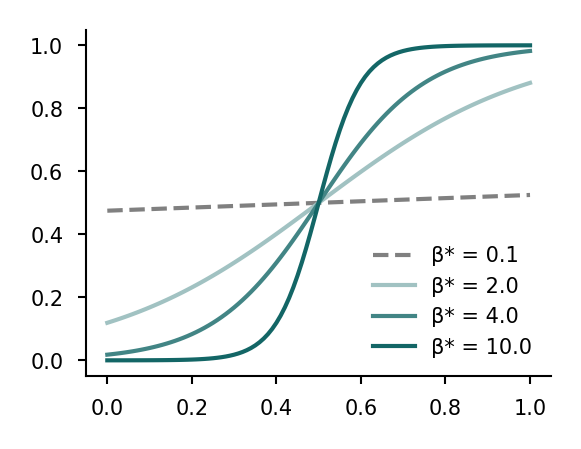

In [8]:
p = np.arange(0,1.01,0.01).reshape(-1,1)

legend_handles = []  
legend_labels = []

fig, ax = plt.subplots(figsize=(2,1.5), dpi=300)

for ii, bb in enumerate(betastars):
    curve = softmax(bb*np.concatenate((p,1-p),axis=1),axis=1)
    if ii == 0:
        line, = ax.plot(p, curve[:, 0],'--', c='gray', label=f'β* = {bb}',linewidth=1)
    else:
        line, = ax.plot(p,curve[:,0],c=cmap_t(1-get_color(ii,betastars,0,5)), label=f'β = {bb}',linewidth=1)
    legend_handles.append(line)
    legend_labels.append(f'β* = {bb}')
format_axis(ax)
ax.legend(legend_handles, legend_labels, fontsize=5, frameon=False, loc='lower right')
savefig(fig, 'Figure2/figure2_softmax_PFs')

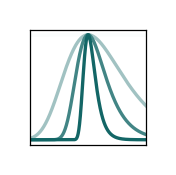

In [9]:
from scipy.stats import gumbel_r

fig, ax = plt.subplots(figsize=(0.5,0.5), dpi=300)

x = np.arange(-100,100,0.01)
p1 = 0.3
p2 = 0.7

for ii, bb in enumerate(betastars):
    iline2, = ax.plot(x/bb+p2,gumbel_r.pdf(x),c=cmap_t(1-get_color(ii,betastars,0,5)),linewidth=0.8)

ax.set_xlim([p2-1,p2+1])
ylim = ax.get_ylim()
ax.set_ylim(ylim)
ax.set_xticks([])
ax.set_xlabel('', fontsize=5)
ax.set_ylabel('', fontsize=5)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.spines['bottom'].set_linewidth(0.3)
ax.spines['left'].set_linewidth(0.3)
ax.spines['top'].set_linewidth(0.3)
ax.spines['right'].set_linewidth(0.3)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
savefig(fig, 'Figure2/figure2_gumbel')

In [10]:
# get equal-weights heuristic IB bound (IB-optimal for true p(X,Y)) on the experimental trial set
p_XgY_ew = utils.P_shapecomb_g_horse_ew(shapes_Xset,paramdict['highWS']['weakLLR'],paramdict['highWS']['WSratio'],paramdict['highWS']['p1'])
emp_bound_heur = utils.get_IB_bound_emp(shapes_high_emp,shapes_Xset,horses_high_emp,p_XgY_ew,p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads)

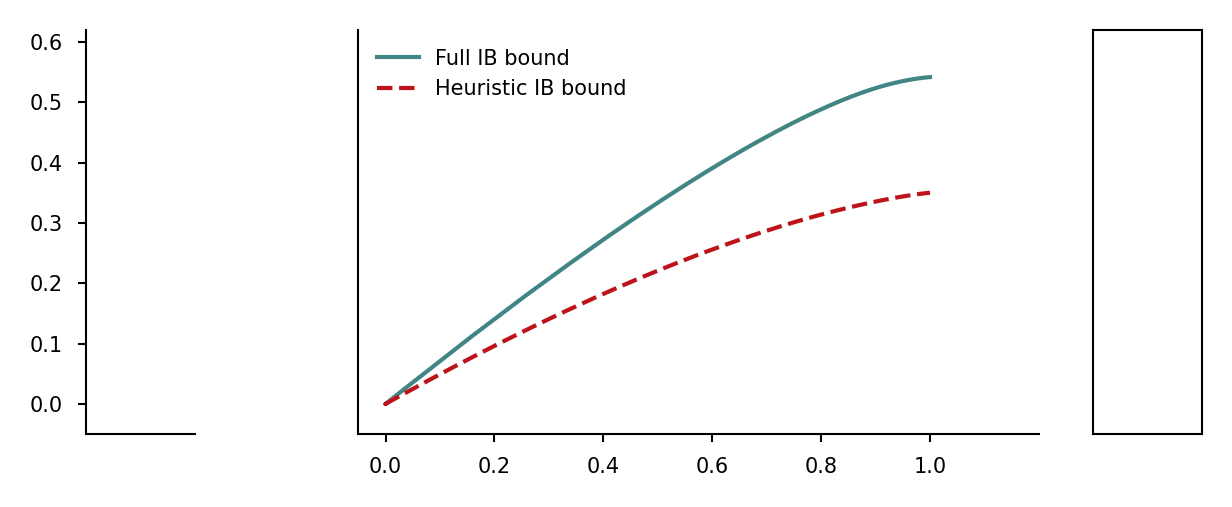

In [11]:
legend_handles = []  
legend_labels = []

# make x scale constant across both subplots
# Calculate width ratio based on x-limits
xlim_left = (0.2 - 0)  # width of left subplot
xlim_mid = (1.2 - (-0.05))  # width of right subplot
xlim_right = (0.2 - 0)  # width of right subplot
width_ratio = [xlim_left, xlim_mid, xlim_right]

# fig, axs = plt.subplots(1, 3, figsize=(4.5, 1.75), dpi=300, gridspec_kw={'width_ratios': width_ratio})
fig = plt.figure(figsize=(4.8, 1.75), dpi=300)

# Create GridSpec with 5 columns: [left_plot, gap1, middle_plot, gap2, right_plot]
# The gaps are just empty space columns
gs = gridspec.GridSpec(1, 5, figure=fig, 
                       width_ratios=[xlim_left, 0.3, xlim_mid, 0.1, xlim_right],
                       wspace=0)  # Set wspace to 0 since we're using gap columns

# Create subplots in non-gap columns
axs = [fig.add_subplot(gs[0, 0]),   # left subplot
       fig.add_subplot(gs[0, 2]),   # middle subplot  
       fig.add_subplot(gs[0, 4])]   # right subplot

axs[0].set_xlim(0,0.2)
axs[0].set_ylim(-0.05,0.62)
axs[0].set_xticks([])
format_axis(axs[0])

fullbound, = axs[1].plot(emp_bound['I_XR'],emp_bound['I_RY'],c=cmap_t(.8),linewidth=1,label='Full IB bound')
heurbound, = axs[1].plot(emp_bound_heur['I_XR'],emp_bound_heur['I_RY'],'--',c=cmap_r(.8),linewidth=1,label='Heuristic IB bound')

format_axis(axs[1])
axs[1].legend(fontsize=5, frameon=False)
axs[1].set_xlim(-0.05,1.2)
axs[1].set_xticks(np.arange(0,1.2,0.2))
axs[1].set_ylim(-0.05,0.62)
axs[1].set_yticks([])

axs[2].set_xlim(0,0.2)
axs[2].set_ylim(-0.05,0.62)
axs[2].set_xticks([])
axs[2].spines['left'].set_linewidth(0.5)
axs[2].spines['right'].set_linewidth(0.5)
axs[2].spines['top'].set_linewidth(0.5)
axs[2].spines['bottom'].set_linewidth(0.5)
axs[2].tick_params(axis='x', labelsize=5, width=0.5, length=2)
axs[2].tick_params(axis='y', labelsize=5, width=0.5, length=2)
axs[2].set_yticks([])
axs[2].set_xticks([])

savefig(fig, 'Figure2/figure2_data_schematic_template')

## Figure 3
IB-analyses of human behavior on the bead-prediction experiment

In [12]:
# compute empirical IB bound for the fully optimal strategy
beads_Xset = utils.get_beads_Xset(wsize)
p_XgY = utils.P_beads_g_jar(beads_Xset,E,H)
emp_bound_opt_beads = utils.get_IB_bound_emp(beads_emp, beads_Xset, jars_emp, p_XgY, p_Y, N_b=N_b_ib, max_b=max_b_ib, iterlimit=IB_iterlimit, N_threads=N_threads)

# compute empirical IB bound for the one-back heuristic strategy
beads_Xset_1b = utils.get_beads_Xset(wsize=1)
beads_emp_1b, jars_emp_1b = utils.getXY_beads(beads_emp_raw, jars_emp_raw, wsize=1)
p_XgY_1b = utils.P_beads_g_jar(beads_Xset_1b,E,H)
emp_bound_heur_beads = utils.get_IB_bound_emp(beads_emp_1b, beads_Xset_1b, jars_emp_1b, p_XgY_1b, p_Y, N_b=N_b_ib, max_b=max_b_ib, iterlimit=IB_iterlimit, N_threads=N_threads)

# compute empirical softmax curve for the fully optimal strategy
p_YgX = utils.P_jar_g_beads(beads_emp,E,H,p_Y)
emp_softmax_curve_opt_beads = utils.get_softmax_IB_curve_emp(beads_emp,jars_emp,p_YgX,N_b=N_b_softmax,max_b=max_b_softmax)

# compute empirical softmax curve for the one-back heuristic strategy
p_YgX_1b = utils.P_jar_g_beads(beads_emp_1b,E,H,p_Y)
emp_softmax_curve_heur_beads = utils.get_softmax_IB_curve_emp(beads_emp_1b,jars_emp_1b,p_YgX_1b,N_b=N_b_softmax,max_b=max_b_softmax)

### Compute IB measures for each run for each participant
And compute CI of $I(R;Y)$

In [13]:
# import preprocessed human behavioral data
datadf_beads = pd.read_csv(beads_datadir + "sj-preproc-data.csv")

if loaddataflag and os.path.exists(beads_datadir + "IB_analysis_data.csv"):
    ibdf_beads = pd.read_csv(beads_datadir + "sj-IB-measures.csv")

else:

    ibdf_beads = pd.DataFrame({
        'subject_ID': [],
        'subject_index': [],
        'run': [],
        'Ixr': [],
        'Iry': [],
        'Iry_CI_lower': [],
        'Iry_CI_upper': []
    })

    Xemp, Yemp = utils.getXY_beads(beads_emp_raw, jars_emp_raw, wsize,encodeX=True)
    Xcard = 2**wsize
    Rcard = 2
    Ycard = 2

    sjlist = datadf_beads['subject_index'].unique()
    for ii,sj in enumerate(sjlist):
        for run in [1,2]:

            sjdf = pd.DataFrame({
                'subject_ID': [''],
                'subject_index': [np.nan],
                'run': [np.nan],
                'Ixr': [np.nan],
                'Iry': [np.nan],
                'Iry_CI_lower': [np.nan],
                'Iry_CI_upper': [np.nan]
            })

            df_ = datadf_beads[(datadf_beads['subject_index']==sj) & (datadf_beads['run']==run)]
            Remp = utils.getR_beads(df_['choice'].to_numpy(),wsize)

            # compute I(X;R) and I(R;Y) for this subject and run
            Ixr = utils.mutual_inf_nsb(Xemp,Remp,[Xcard,Rcard])
            Iry = utils.mutual_inf_nsb(Remp,Yemp,[Rcard,Ycard])

            # compute confidence interval for I(R;Y) for this subject and run
            Iry_CI = utils.get_Iry_CI(Remp,Yemp,CI,boot_iters,Rcard=Rcard,Ycard=Ycard,seed=234,N_threads=N_threads)

            sjdf['subject_ID'] = df_['subject_ID'].iloc[0]
            sjdf['subject_index'] = sj
            sjdf['run'] = run
            sjdf['Ixr'] = Ixr
            sjdf['Iry'] = Iry
            sjdf['Iry_CI_lower'] = Iry_CI[0]
            sjdf['Iry_CI_upper'] = Iry_CI[1]

            ibdf_beads = pd.concat((ibdf_beads, sjdf), ignore_index=True)

    # compute information efficiency for each subject and run
    ibdf_beads['info_efficiency'] = ibdf_beads['Iry'] / np.interp(ibdf_beads['Ixr'],emp_bound_opt_beads['I_XR'], emp_bound_opt_beads['I_RY'])

    # classify each subject and run according to which IB bound (fully optimal or heuristic) they are closest to, among those that are consistent with their confidence interval for I(R;Y)
    ibdf_beads['bound_class'] = utils.classify_by_bound(ibdf_beads['Ixr'], ibdf_beads['Iry'], ibdf_beads['Iry_CI_lower'], ibdf_beads['Iry_CI_upper'], [emp_bound_opt_beads, emp_bound_heur_beads], bound_labels=['full', '1back'])

/usr/local/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/usr/local/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/usr/local/lib/python3.11/site-packages/matplotlib/cbook.py:1699: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


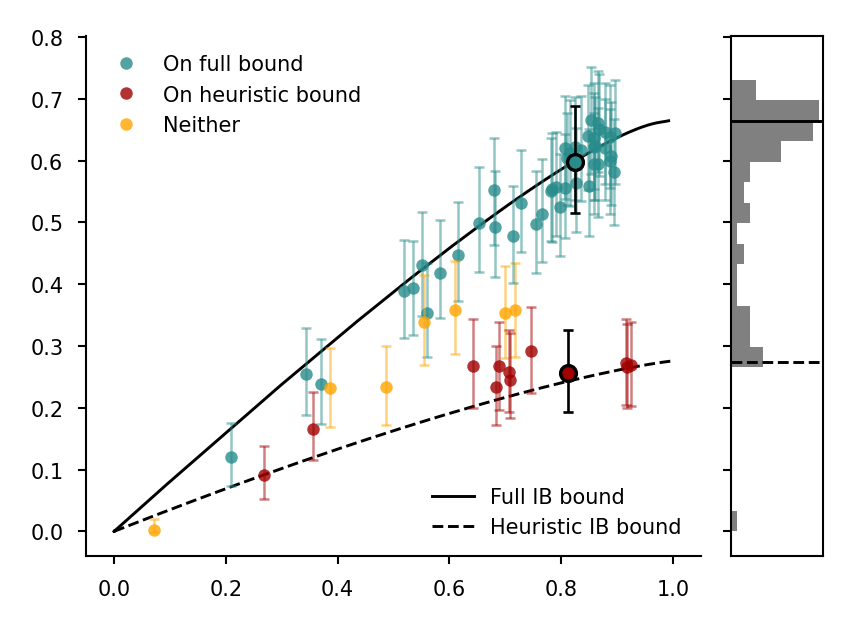

In [14]:
# plot subject data in IB space for run 2
# EXCLUDE those with I(X;R) < 0.05

highlighted_sjs = [6, 54]

alpha_dot = 0.8
alpha_line = 0.5

conds = (ibdf_beads['Ixr'] >= 0.05) & (ibdf_beads['run']==2)

fig, ax = plt.subplots(figsize=(3, 2.2), dpi=300)

full_bound, = ax.plot(emp_bound_opt_beads['I_XR'], emp_bound_opt_beads['I_RY'], 'k', linewidth=0.7, label='Full IB bound')
heur_bound, = ax.plot(emp_bound_heur_beads['I_XR'], emp_bound_heur_beads['I_RY'], '--k', linewidth=0.7, label='Heuristic IB bound')

for sjind in pd.unique(ibdf_beads[conds]['subject_index']):
    sjconds = conds & (ibdf_beads['subject_index'] == sjind)
    if ibdf_beads[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onfullbound, = ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif ibdf_beads[sjconds]['bound_class'].to_numpy() == '1back':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onheurbound, = ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif ibdf_beads[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=nonecolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        other, = ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=nonecolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')

high_color = 'black'
high_width = 0.8
high_alpha = 1.0
for sjind in highlighted_sjs:
    sjconds = conds & (ibdf_beads[conds]['subject_index'] == sjind)
    if ibdf_beads[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=optcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_beads[sjconds]['bound_class'].to_numpy() == '1back':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=heurcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_beads[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_beads[sjconds]['Ixr'], ibdf_beads[sjconds]['Iry'], yerr=[ibdf_beads[sjconds]['Iry'] - ibdf_beads[sjconds]['Iry_CI_lower'], ibdf_beads[sjconds]['Iry_CI_upper'] - ibdf_beads[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_beads[sjconds]['Ixr'],ibdf_beads[sjconds]['Iry'],'o',c=nonecolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)

leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[full_bound, heur_bound],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)

format_axis(ax)

Iry_interp_opt = np.interp(ibdf_beads.loc[conds,'Ixr'], emp_bound_opt_beads['I_XR'], emp_bound_opt_beads['I_RY'])
Iry_interp_1b = np.interp(ibdf_beads.loc[conds,'Ixr'], emp_bound_heur_beads['I_XR'], emp_bound_heur_beads['I_RY'])
relative_heur = Iry_interp_1b / Iry_interp_opt

avg_rel_1b = relative_heur.mean()
yvals_norm = ibdf_beads.loc[conds,'info_efficiency'].to_numpy() * emp_bound_opt_beads['I_RY'].max()
bins = (np.arange(0,1.2,0.05)) * emp_bound_opt_beads['I_RY'].max()
counts, bins = np.histogram(yvals_norm, bins=bins)

ax_hist = ax.inset_axes([1.05, 0, 0.15, 1], sharey=ax)
ax_hist.barh((bins[:-1] + bins[1:]) / 2, counts, height=(bins[1] - bins[0]), color='gray')
ax_hist.axhline(emp_bound_opt_beads['I_RY'].max(), color='black', linestyle='-', linewidth=0.7)
ax_hist.axhline(avg_rel_1b * emp_bound_opt_beads['I_RY'].max(), color='black', linestyle='--', linewidth=0.7)
# ax_hist.set_xlabel('Count')
ax_hist.set_ylabel('')
# ax_hist.set_yticks([])
ax_hist.tick_params(axis='y', labelleft=False, labelsize=5, width=0.5, length=2)
ax_hist.set_xticks([])
ax_hist.set_ylim(ax.get_ylim())
ax_hist.grid(False)
ax_hist.spines['bottom'].set_linewidth(0.5)
ax_hist.spines['left'].set_linewidth(0.5)
ax_hist.spines['top'].set_linewidth(0.5)
ax_hist.spines['right'].set_linewidth(0.5)
plt.tight_layout()
savefig(fig, 'Figure3/figure3_beads_IBplot')

/workspaces/human-inference-IB/utilities.py:678: RuntimeWarning: divide by zero encountered in log
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
/workspaces/human-inference-IB/utilities.py:678: RuntimeWarning: invalid value encountered in multiply
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
/workspaces/human-inference-IB/utilities.py:678: RuntimeWarning: divide by zero encountered in log
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
/workspaces/human-inference-IB/utilities.py:678: RuntimeWarning: invalid value encountered in multiply
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
/workspaces/human-inference-IB/utilities.py:678: RuntimeWarning: divide by zero encountered in log
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
/workspaces/human-inference-IB/utilities.py:678: RuntimeWarning: invalid value encountered in multiply
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))


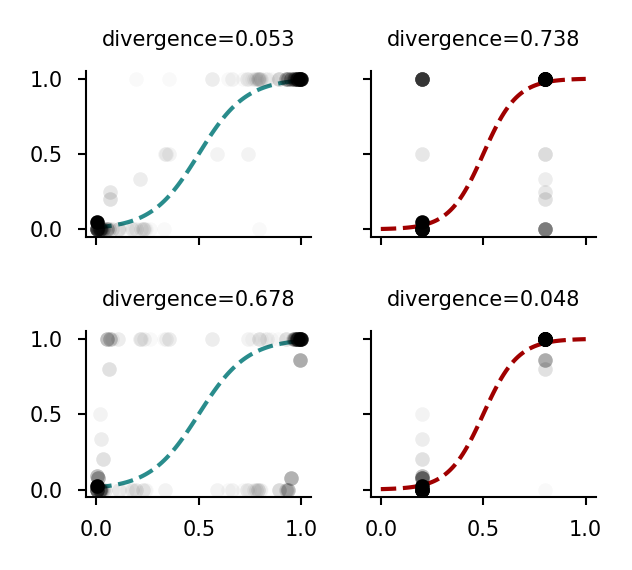

In [15]:
# psychometric functions for highlighted subjects, compared to IB-predicted psychometric functions for each bound (full and heuristic)

choicedf_beads = pd.read_csv(beads_datadir + 'sj-psychometric-data.csv')
postdf_beads = pd.read_csv(beads_datadir + 'strat-post-probs.csv')

fig, axs = plt.subplots(2,2, figsize=(2.25,2), dpi=300)

strats = ['fully-optimal','1-back']
strat_colors = {
    'fully-optimal': optcolor,
    '1-back': heurcolor
}
strat_bounds = {
    'fully-optimal': emp_softmax_curve_opt_beads,
    '1-back': emp_softmax_curve_heur_beads
}
conds1 = (choicedf_beads['run']==2)
conds2 = (ibdf_beads['run']==2)

for ii, sj in enumerate(highlighted_sjs):
    sjconds1 = conds1 & (choicedf_beads['subject_index'] == sj)
    sjconds2 = conds2 & (ibdf_beads['subject_index'] == sj)
    for jj, strat in enumerate(strats):
        utils.get_IB_predicted_psychometric_plot(ibdf_beads.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat],strat_colors[strat],axs[ii,jj])
        utils.get_sj_psychometric_plot(choicedf_beads.loc[sjconds1], postdf_beads.loc[postdf_beads['strategy']==strat], axs[ii,jj])
        dkl = utils.get_psychometric_DKL(choicedf_beads.loc[sjconds1], postdf_beads.loc[postdf_beads['strategy']==strat],ibdf_beads.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat])
        format_axis(axs[ii,jj])
        axs[ii,jj].set_title(f'divergence={dkl:.3f}', fontsize=5)
        if ii == 0:
            axs[ii,jj].set_xticklabels([])
        if jj == 1:
            axs[ii,jj].set_yticklabels([])
plt.tight_layout()
savefig(fig, 'Figure3/figure3_beads_PMFs')

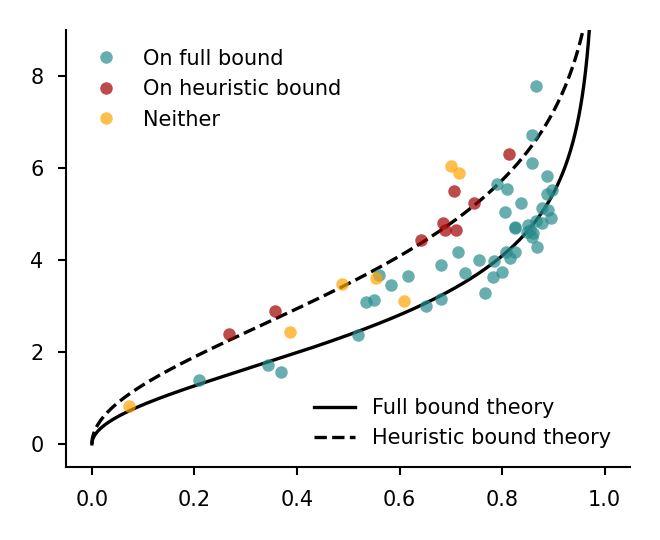

In [16]:
# plot choice noise term (best-fitting model betastar) vs I(X;R) for run 2
# EXCLUDE those with I(X;R) < 0.05

modeldf_beads = pd.read_csv(beads_datadir + 'model_fits.csv')
alldata_beads = pd.merge(ibdf_beads, modeldf_beads, on=['subject_ID', 'subject_index', 'run'])

conds = (alldata_beads['Ixr'] >= 0.05) & (alldata_beads['run']==2)

fig, ax = plt.subplots(figsize=(2.3, 1.9), dpi=300)

ib_theory, = ax.plot(emp_softmax_curve_opt_beads['I_XR'], emp_softmax_curve_opt_beads['betastar'], 'k', alpha=1,linewidth=0.8,label='Full bound theory')
heur_theory, = ax.plot(emp_softmax_curve_heur_beads['I_XR'], emp_softmax_curve_heur_beads['betastar'], '--k', alpha=1,linewidth=0.8,label='Heuristic bound theory')

for sjind in pd.unique(alldata_beads.loc[conds,'subject_index']):
    sjconds = conds & (alldata_beads['subject_index'] == sjind)
    if (alldata_beads.loc[conds & (alldata_beads['subject_index'] == sjind),'bound_class'].to_numpy() == 'full'):
        onfullbound, = ax.plot(alldata_beads.loc[sjconds,'Ixr'],alldata_beads.loc[sjconds,'best_model_betastar'],'o',c=optcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif alldata_beads.loc[conds & (alldata_beads['subject_index'] == sjind),'bound_class'].to_numpy() == '1back':
        onheurbound, = ax.plot(alldata_beads.loc[sjconds,'Ixr'],alldata_beads.loc[sjconds,'best_model_betastar'],'o',c=heurcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif alldata_beads.loc[conds & (alldata_beads['subject_index'] == sjind),'bound_class'].to_numpy() == 'none':
        other, = ax.plot(alldata_beads.loc[sjconds,'Ixr'],alldata_beads.loc[sjconds,'best_model_betastar'],'o',c=nonecolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')
leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[ib_theory, heur_theory],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)
ax.set_ylim(-0.5,9)
format_axis(ax)
plt.tight_layout()

## Figure 4
IB-analyses of human behavior on the horse prediction experiments

In [44]:
# conds = ['lowWS','midWS','highWS']
conds = ['highWS']
# strats = ['full','equal-weights','ignore-weak']
strats = ['full','equal-weights']

P_XgY_dict = {
    'full': utils.P_shapecomb_g_horse,
    'equal-weights': utils.P_shapecomb_g_horse_ew,
    'ignore-weak': utils.P_shapecomb_g_horse_iw
}

shapes_Xset = utils.get_shapes_Xset()

p_XgY_dict = {}
for cond in conds:
    p_XgY_dict[cond] = {}
    for strat in strats:
        p_XgY_dict[cond][strat] = P_XgY_dict[strat](shapes_Xset,paramdict[cond]['weakLLR'],paramdict[cond]['WSratio'],paramdict[cond]['p1'])

bound_dict_horses = {}
for cond in conds:
    bound_dict_horses[cond] = {}
    for strat in strats:
        bound_dict_horses[cond][strat] = utils.get_IB_bound_emp(shapes_emp_dict[cond],shapes_Xset,horses_emp_dict[cond],p_XgY_dict[cond][strat],p_Y,N_b=N_b_ib,max_b=max_b_ib,iterlimit=IB_iterlimit,N_threads=N_threads)

softmax_dict_horses = {}
for cond in conds:
    softmax_dict_horses[cond] = {}
    for strat in strats:
        p_YgX_emp = utils.P_horse_g_shapecomb(shapes_emp_dict[cond],paramdict[cond]['weakLLR'],paramdict[cond]['WSratio'],paramdict[cond]['p1'],p_Y=p_Y, P_XgY=P_XgY_dict[strat])
        softmax_dict_horses[cond][strat] = utils.get_softmax_IB_curve_emp(shapes_emp_dict[cond],horses_emp_dict[cond],p_YgX_emp,N_b=N_b_softmax,max_b=max_b_softmax)

In [7]:
import pickle

with open(horses_datadir + 'IB_bounds.pkl', 'wb') as f:
    pickle.dump({
        'bound_dict_horses': bound_dict_horses,
        'softmax_dict_horses': softmax_dict_horses
    }, f)

### Compute IB measures for each run for each participant (and for each experiment)
And compute CI of $I(R;Y)$

In [5]:
exps1 = ['lowWS','midWS','highWS']
exps2 = ['learning','reward','speed_accuracy']
conds_dict = {
    'learning': ['run_1', 'run_2'],
    'reward': ['low_reward', 'high_reward'],
    'speed_accuracy': ['fast', 'slow']
}

preproc_dict = {
    'lowWS': pd.read_csv(horses_datadir + "lowWS/sj-preproc-data.csv"),
    'midWS': pd.read_csv(horses_datadir + "midWS_learning/sj-preproc-data.csv"),
    'highWS': pd.read_csv(horses_datadir + "highWS/sj-preproc-data.csv"),
    'learning': pd.read_csv(horses_datadir + "midWS_learning/sj-preproc-data.csv"),
    'reward': pd.read_csv(horses_datadir + "reward/sj-preproc-data.csv"),
    'speed_accuracy': pd.read_csv(horses_datadir + "speed_accuracy/sj-preproc-data.csv")
}

ibdf_dict = {}

Xcard = 56 # number of unique shape combinations for five samples from four shapes (with replacement)
Rcard = 2
Ycard = 2

# in this loop, all trials for the mid-WS/learning experiment (mid-WS) are included, but not separated by run (since lack of group learning effect, see paper)
for exp in exps1:
    ibdf_ = pd.DataFrame({
        'subject_ID': [],
        'subject_index': [],
        'exclude_Ixr': [],
        'Ixr': [],
        'Iry': [],
        'Iry_CI_lower': [],
        'Iry_CI_upper': []
    })
    sjlist = preproc_dict[exp]['subject_index'].unique()
    for ii,sj in enumerate(sjlist):
        sjconds = (preproc_dict[exp]['subject_index'] == sj)
        shapes_emp = preproc_dict[exp][sjconds]['observation_encoding'].to_numpy()
        horses_emp = preproc_dict[exp][sjconds]['latent_state'].to_numpy()
        choices = preproc_dict[exp][sjconds]['choice'].to_numpy()

        # compute I(X;R) and I(R;Y) for this subject and run
        Ixr = utils.mutual_inf_nsb(shapes_emp, choices, [Xcard, Rcard])
        Iry = utils.mutual_inf_nsb(choices, horses_emp, [Rcard, Ycard])

        # compute confidence interval for I(R;Y) for this subject and run
        Iry_CI = utils.get_Iry_CI(choices, horses_emp, CI, boot_iters, Rcard=Rcard, Ycard=Ycard, seed=234, N_threads=N_threads)

        if exp == 'midWS':
            exclude_Ixr = int(Ixr < 0.05)
        else:
            exclude_Ixr = int(preproc_dict[exp][sjconds]['exclude_Ixr'].iloc[0])

        sjdf = pd.DataFrame({
            'subject_ID': [preproc_dict[exp][sjconds]['subject_ID'].iloc[0]],
            'subject_index': [sj],
            'exclude_Ixr': [exclude_Ixr],
            'Ixr': [Ixr],
            'Iry': [Iry],
            'Iry_CI_lower': [Iry_CI[0]],
            'Iry_CI_upper': [Iry_CI[1]]
        })
        ibdf_ = pd.concat((ibdf_, sjdf), ignore_index=True)

     # compute information efficiency for each subject and run
    ibdf_['info_efficiency'] = ibdf_['Iry'] / np.interp(ibdf_['Ixr'],bound_dict_horses[exp]['full']['I_XR'], bound_dict_horses[exp]['full']['I_RY'])

    # classify each subject and run according to which IB bound (fully optimal or heuristic) they are closest to, among those that are consistent with their confidence interval for I(R;Y)
    ibdf_['bound_class'] = utils.classify_by_bound(ibdf_['Ixr'], ibdf_['Iry'], ibdf_['Iry_CI_lower'], ibdf_['Iry_CI_upper'], [bound_dict_horses[exp]['full'], bound_dict_horses[exp]['equal-weights']], bound_labels=['full', 'equal-weights'])

    ibdf_dict[exp] = ibdf_.copy()

# in this loop, trials for the mid-WS/learning experiment are grouped by run for examination learning/repetition effects
for exp in exps2:
    ibdf_ = pd.DataFrame({
        'subject_ID': [],
        'subject_index': [],
        'exclude_Ixr': [],
        'condition': [],
        'Ixr': [],
        'Iry': [],
        'Iry_CI_lower': [],
        'Iry_CI_upper': []
    })
    sjlist = preproc_dict[exp]['subject_index'].unique()
    for ii,sj in enumerate(sjlist):
        for jj in range(len(conds_dict[exp])):
            sjconds = (preproc_dict[exp]['subject_index'] == sj) & (preproc_dict[exp]['condition'] == conds_dict[exp][jj])
            shapes_emp = preproc_dict[exp][sjconds]['observation_encoding'].to_numpy()
            horses_emp = preproc_dict[exp][sjconds]['latent_state'].to_numpy()
            choices = preproc_dict[exp][sjconds]['choice'].to_numpy()

            # compute I(X;R) and I(R;Y) for this subject and run
            Ixr = utils.mutual_inf_nsb(shapes_emp, choices, [Xcard, Rcard])
            Iry = utils.mutual_inf_nsb(choices, horses_emp, [Rcard, Ycard])

            # compute confidence interval for I(R;Y) for this subject and run
            Iry_CI = utils.get_Iry_CI(choices, horses_emp, CI, boot_iters, Rcard=Rcard, Ycard=Ycard, seed=234, N_threads=N_threads)

            sjdf = pd.DataFrame({
                'subject_ID': [preproc_dict[exp][sjconds]['subject_ID'].iloc[0]],
                'subject_index': [sj],
                'exclude_Ixr': [preproc_dict[exp][sjconds]['exclude_Ixr'].iloc[0]],
                'condition': [conds_dict[exp][jj]],
                'Ixr': [Ixr],
                'Iry': [Iry],
                'Iry_CI_lower': [Iry_CI[0]],
                'Iry_CI_upper': [Iry_CI[1]]
            })
            ibdf_ = pd.concat((ibdf_, sjdf), ignore_index=True)

    # compute information efficiency for each subject and run
    ibdf_['info_efficiency'] = ibdf_['Iry'] / np.interp(ibdf_['Ixr'],bound_dict_horses['midWS']['full']['I_XR'], bound_dict_horses['midWS']['full']['I_RY']) # all these experiments use the intermidate WS trial set

    # classify each subject and run according to which IB bound (fully optimal or heuristic) they are closest to, among those that are consistent with their confidence interval for I(R;Y)
    ibdf_['bound_class'] = utils.classify_by_bound(ibdf_['Ixr'], ibdf_['Iry'], ibdf_['Iry_CI_lower'], ibdf_['Iry_CI_upper'], [bound_dict_horses['midWS']['full'], bound_dict_horses['midWS']['equal-weights']], bound_labels=['full', 'equal-weights'])

    ibdf_dict[exp] = ibdf_.copy()

alldata_dict = {}


In [6]:
ibdf_dict['lowWS'].to_csv(horses_datadir + 'lowWS/sj-IB-measures.csv', index=False)
ibdf_dict['midWS'].to_csv(horses_datadir + 'midWS_learning/midWS_sj-IB-measures.csv', index=False)
ibdf_dict['highWS'].to_csv(horses_datadir + 'highWS/sj-IB-measures.csv', index=False)
ibdf_dict['learning'].to_csv(horses_datadir + 'midWS_learning/learning_sj-IB-measures.csv', index=False)
ibdf_dict['reward'].to_csv(horses_datadir + 'reward/sj-IB-measures.csv', index=False)
ibdf_dict['speed_accuracy'].to_csv(horses_datadir + 'speed_accuracy/sj-IB-measures.csv', index=False)

#### Low WS-ratio experiment

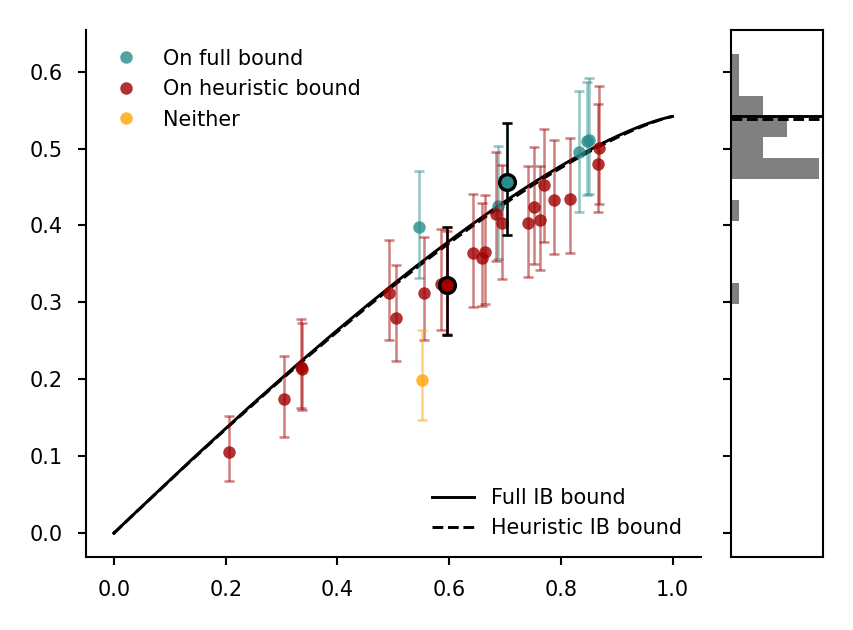

In [8]:
# plot subject data in IB space
# EXCLUDE those with I(X;R) < 0.05

highlighted_sjs = [26, 15]
exp = 'lowWS'
stats = 'lowWS'

alpha_dot = 0.8
alpha_line = 0.5

ibdf_ = ibdf_dict[exp].copy()

conds = (ibdf_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(3, 2.2), dpi=300)

full_bound, = ax.plot(bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'], 'k', linewidth=0.7, label='Full IB bound')
heur_bound, = ax.plot(bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Heuristic IB bound')

for sjind in pd.unique(ibdf_[conds]['subject_index']):
    sjconds = conds & (ibdf_['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onfullbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onheurbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=nonecolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        other, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')

high_color = 'black'
high_width = 0.8
high_alpha = 1.0
for sjind in highlighted_sjs:
    sjconds = conds & (ibdf_[conds]['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)

leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[full_bound, heur_bound],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)

format_axis(ax)

# Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_heur = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'])
heur_efficiency = Iry_interp_heur / np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])

avg_rel_heur = heur_efficiency.mean()
yvals_norm = ibdf_.loc[conds,'info_efficiency'].to_numpy() * bound_dict_horses[stats]['full']['I_RY'].max()
bins = (np.arange(0,1.2,0.05)) * bound_dict_horses[stats]['full']['I_RY'].max()
counts, bins = np.histogram(yvals_norm, bins=bins)

ax_hist = ax.inset_axes([1.05, 0, 0.15, 1], sharey=ax)
ax_hist.barh((bins[:-1] + bins[1:]) / 2, counts, height=(bins[1] - bins[0]), color='gray')
ax_hist.axhline(bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='-', linewidth=0.7)
ax_hist.axhline(avg_rel_heur * bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='--', linewidth=0.7)
# ax_hist.set_xlabel('Count')
ax_hist.set_ylabel('')
# ax_hist.set_yticks([])
ax_hist.tick_params(axis='y', labelleft=False, labelsize=5, width=0.5, length=2)
ax_hist.set_xticks([])
ax_hist.set_ylim(ax.get_ylim())
ax_hist.grid(False)
ax_hist.spines['bottom'].set_linewidth(0.5)
ax_hist.spines['left'].set_linewidth(0.5)
ax_hist.spines['top'].set_linewidth(0.5)
ax_hist.spines['right'].set_linewidth(0.5)
plt.tight_layout()
savefig(fig, 'Figure4/figure4_horses_lowWS_IBplot')

c:\Users\parja\Projects\human-inference-IB\utilities.py:678: RuntimeWarning: divide by zero encountered in log
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
c:\Users\parja\Projects\human-inference-IB\utilities.py:678: RuntimeWarning: invalid value encountered in multiply
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))


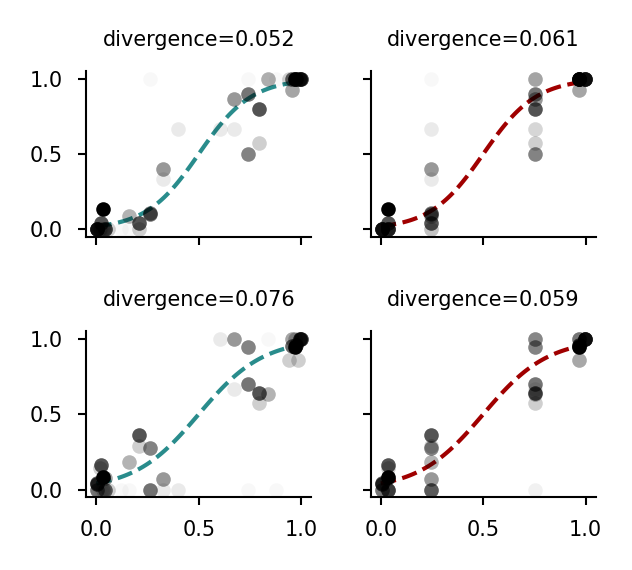

In [9]:
# psychometric functions for highlighted subjects, compared to IB-predicted psychometric functions for each bound (full and heuristic)

exp = 'lowWS'
stats = 'lowWS'

choicedf_ = pd.read_csv(horses_datadir + 'lowWS/sj-psychometric-data.csv')
postdf_ = pd.read_csv(horses_datadir + 'lowWS/strat-post-probs.csv')

ibdf_ = ibdf_dict[exp].copy()

fig, axs = plt.subplots(2,2, figsize=(2.25,2), dpi=300)

strats = ['fully-optimal','equal-weights']
strat_colors = {
    'fully-optimal': optcolor,
    'equal-weights': heurcolor
}
strat_bounds = {
    'fully-optimal': softmax_dict_horses[stats]['full'],
    'equal-weights': softmax_dict_horses[stats]['equal-weights']
}
conds1 = (choicedf_['subject_index'].notna())
conds2 = (ibdf_['subject_index'].notna())

for ii, sj in enumerate(highlighted_sjs):
    sjconds1 = conds1 & (choicedf_['subject_index'] == sj)
    sjconds2 = conds2 & (ibdf_['subject_index'] == sj)
    for jj, strat in enumerate(strats):
        utils.get_IB_predicted_psychometric_plot(ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat],strat_colors[strat],axs[ii,jj])
        utils.get_sj_psychometric_plot(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat], axs[ii,jj])
        dkl = utils.get_psychometric_DKL(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat],ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat])
        format_axis(axs[ii,jj])
        axs[ii,jj].set_title(f'divergence={dkl:.3f}', fontsize=5)
        if ii == 0:
            axs[ii,jj].set_xticklabels([])
        if jj == 1:
            axs[ii,jj].set_yticklabels([])
plt.tight_layout()

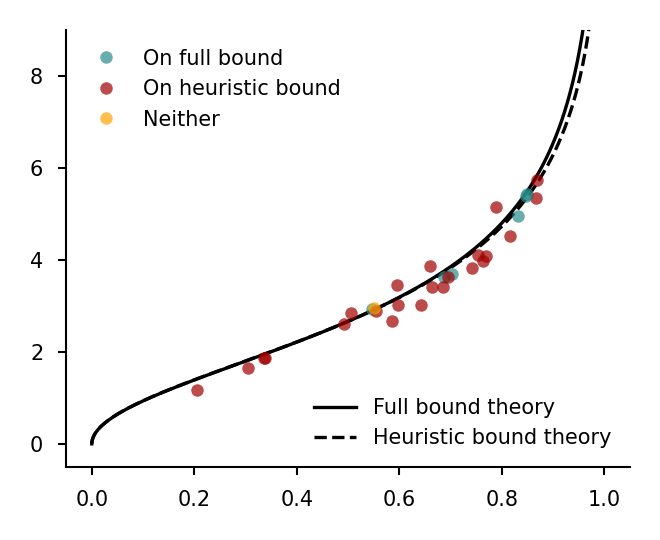

In [10]:
# plot choice noise term (best-fitting model betastar) vs I(X;R)
# EXCLUDE those with I(X;R) < 0.05

modeldf_ = pd.read_csv(horses_datadir + 'lowWS/model_fits.csv')
alldata_ = pd.merge(ibdf_, modeldf_, on=['subject_ID', 'subject_index'])

exp = 'lowWS'
stats = 'lowWS'

conds = (alldata_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(2.3, 1.9), dpi=300)

ib_theory, = ax.plot(softmax_dict_horses[stats]['full']['I_XR'], softmax_dict_horses[stats]['full']['betastar'], 'k', alpha=1,linewidth=0.8,label='Full bound theory')
heur_theory, = ax.plot(softmax_dict_horses[stats]['equal-weights']['I_XR'], softmax_dict_horses[stats]['equal-weights']['betastar'], '--k', alpha=1,linewidth=0.8,label='Heuristic bound theory')

for sjind in pd.unique(alldata_.loc[conds,'subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if (alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'full'):
        onfullbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=optcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'equal-weights':
        onheurbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=heurcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'none':
        other, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=nonecolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')
leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[ib_theory, heur_theory],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)
ax.set_ylim(-0.5,9)
format_axis(ax)
plt.tight_layout()

### Intermediate WS-ratio experiment

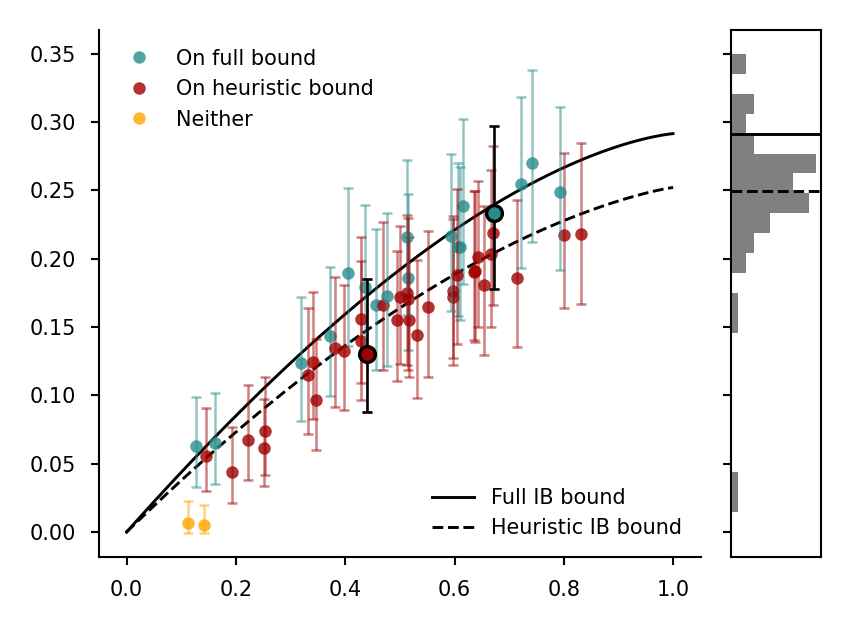

In [39]:
# plot subject data in IB space
# EXCLUDE those with I(X;R) < 0.05

highlighted_sjs = [10, 42]
exp = 'midWS'
stats = 'midWS'

alpha_dot = 0.8
alpha_line = 0.5

ibdf_ = ibdf_dict[exp].copy()

conds = (ibdf_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(3, 2.2), dpi=300)

full_bound, = ax.plot(bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'], 'k', linewidth=0.7, label='Full IB bound')
heur_bound, = ax.plot(bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Heuristic IB bound')

for sjind in pd.unique(ibdf_[conds]['subject_index']):
    sjconds = conds & (ibdf_['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onfullbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onheurbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=nonecolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        other, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')

high_color = 'black'
high_width = 0.8
high_alpha = 1.0
for sjind in highlighted_sjs:
    sjconds = conds & (ibdf_[conds]['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)

leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[full_bound, heur_bound],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)

format_axis(ax)

# Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_heur = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'])
heur_efficiency = Iry_interp_heur / np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])

avg_rel_heur = heur_efficiency.mean()
yvals_norm = ibdf_.loc[conds,'info_efficiency'].to_numpy() * bound_dict_horses[stats]['full']['I_RY'].max()
bins = (np.arange(0,1.25,0.05)) * bound_dict_horses[stats]['full']['I_RY'].max()
counts, bins = np.histogram(yvals_norm, bins=bins)

ax_hist = ax.inset_axes([1.05, 0, 0.15, 1], sharey=ax)
ax_hist.barh((bins[:-1] + bins[1:]) / 2, counts, height=(bins[1] - bins[0]), color='gray')
ax_hist.axhline(bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='-', linewidth=0.7)
ax_hist.axhline(avg_rel_heur * bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='--', linewidth=0.7)
# ax_hist.set_xlabel('Count')
ax_hist.set_ylabel('')
# ax_hist.set_yticks([])
ax_hist.tick_params(axis='y', labelleft=False, labelsize=5, width=0.5, length=2)
ax_hist.set_xticks([])
ax_hist.set_ylim(ax.get_ylim())
ax_hist.grid(False)
ax_hist.spines['bottom'].set_linewidth(0.5)
ax_hist.spines['left'].set_linewidth(0.5)
ax_hist.spines['top'].set_linewidth(0.5)
ax_hist.spines['right'].set_linewidth(0.5)
plt.tight_layout()
savefig(fig, 'Figure4/figure4_horses_midWS_IBplot')

c:\Users\parja\Projects\human-inference-IB\utilities.py:678: RuntimeWarning: divide by zero encountered in log
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
c:\Users\parja\Projects\human-inference-IB\utilities.py:678: RuntimeWarning: invalid value encountered in multiply
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))


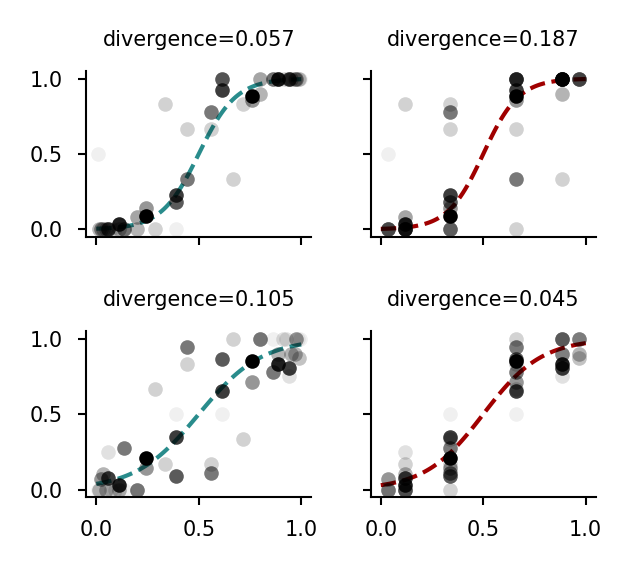

In [40]:
# psychometric functions for highlighted subjects, compared to IB-predicted psychometric functions for each bound (full and heuristic)

exp = 'midWS'
stats = 'midWS'

choicedf_ = pd.read_csv(horses_datadir + 'midWS_learning/midWS_sj-psychometric-data.csv')
postdf_ = pd.read_csv(horses_datadir + 'midWS_learning/strat-post-probs.csv')

ibdf_ = ibdf_dict[exp].copy()

fig, axs = plt.subplots(2,2, figsize=(2.25,2), dpi=300)

strats = ['fully-optimal','equal-weights']
strat_colors = {
    'fully-optimal': optcolor,
    'equal-weights': heurcolor
}
strat_bounds = {
    'fully-optimal': softmax_dict_horses[stats]['full'],
    'equal-weights': softmax_dict_horses[stats]['equal-weights']
}
conds1 = (choicedf_['subject_index'].notna())
conds2 = (ibdf_['subject_index'].notna())

for ii, sj in enumerate(highlighted_sjs):
    sjconds1 = conds1 & (choicedf_['subject_index'] == sj)
    sjconds2 = conds2 & (ibdf_['subject_index'] == sj)
    for jj, strat in enumerate(strats):
        utils.get_IB_predicted_psychometric_plot(ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat],strat_colors[strat],axs[ii,jj])
        utils.get_sj_psychometric_plot(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat], axs[ii,jj])
        dkl = utils.get_psychometric_DKL(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat],ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat])
        format_axis(axs[ii,jj])
        axs[ii,jj].set_title(f'divergence={dkl:.3f}', fontsize=5)
        if ii == 0:
            axs[ii,jj].set_xticklabels([])
        if jj == 1:
            axs[ii,jj].set_yticklabels([])
plt.tight_layout()

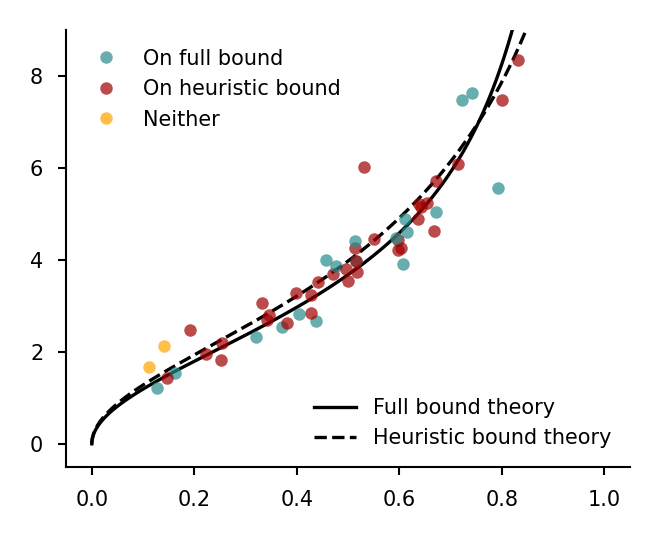

In [43]:
# plot choice noise term (best-fitting model betastar) vs I(X;R)
# EXCLUDE those with I(X;R) < 0.05

modeldf_ = pd.read_csv(horses_datadir + 'midWS_learning/midWS_model_fits.csv')
alldata_ = pd.merge(ibdf_, modeldf_, on=['subject_ID', 'subject_index'])

exp = 'midWS'
stats = 'midWS'

conds = (alldata_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(2.3, 1.9), dpi=300)

ib_theory, = ax.plot(softmax_dict_horses[stats]['full']['I_XR'], softmax_dict_horses[stats]['full']['betastar'], 'k', alpha=1,linewidth=0.8,label='Full bound theory')
heur_theory, = ax.plot(softmax_dict_horses[stats]['equal-weights']['I_XR'], softmax_dict_horses[stats]['equal-weights']['betastar'], '--k', alpha=1,linewidth=0.8,label='Heuristic bound theory')

for sjind in pd.unique(alldata_.loc[conds,'subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if (alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'full'):
        onfullbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=optcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'equal-weights':
        onheurbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=heurcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'none':
        other, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=nonecolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')
leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[ib_theory, heur_theory],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)
ax.set_ylim(-0.5,9)
format_axis(ax)
plt.tight_layout()

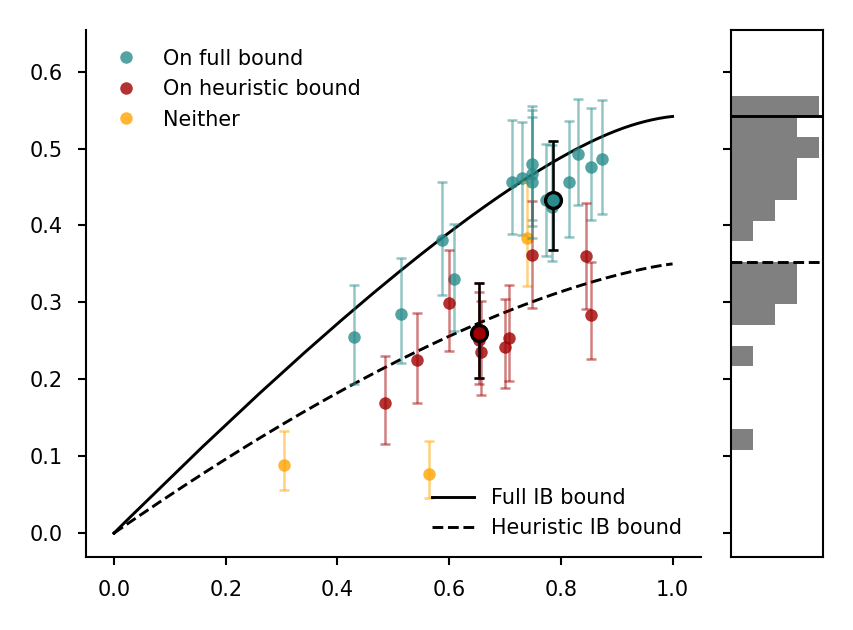

In [47]:
# plot subject data in IB space
# EXCLUDE those with I(X;R) < 0.05

highlighted_sjs = [55, 38]
exp = 'highWS'
stats = 'highWS'

alpha_dot = 0.8
alpha_line = 0.5

ibdf_ = ibdf_dict[exp].copy()

conds = (ibdf_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(3, 2.2), dpi=300)

full_bound, = ax.plot(bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'], 'k', linewidth=0.7, label='Full IB bound')
heur_bound, = ax.plot(bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'], '--k', linewidth=0.7, label='Heuristic IB bound')

for sjind in pd.unique(ibdf_[conds]['subject_index']):
    sjconds = conds & (ibdf_['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=optcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onfullbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=heurcolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        onheurbound, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=nonecolor, alpha=alpha_line, linewidth=0.6, capsize=1.2, capthick=0.6)
        other, = ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=alpha_dot,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')

high_color = 'black'
high_width = 0.8
high_alpha = 1.0
for sjind in highlighted_sjs:
    sjconds = conds & (ibdf_[conds]['subject_index'] == sjind)
    if ibdf_[sjconds]['bound_class'].to_numpy() == 'full':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=optcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'equal-weights':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=heurcolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)
    elif ibdf_[sjconds]['bound_class'].to_numpy() == 'none':
        ax.errorbar(ibdf_[sjconds]['Ixr'], ibdf_[sjconds]['Iry'], yerr=[ibdf_[sjconds]['Iry'] - ibdf_[sjconds]['Iry_CI_lower'], ibdf_[sjconds]['Iry_CI_upper'] - ibdf_[sjconds]['Iry']], fmt='none', ecolor=high_color, alpha=high_alpha, linewidth=0.6, capsize=1.2, capthick=0.6)
        ax.plot(ibdf_[sjconds]['Ixr'],ibdf_[sjconds]['Iry'],'o',c=nonecolor,alpha=high_alpha,markersize=3.8,markeredgewidth=high_width,markeredgecolor=high_color)

leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[full_bound, heur_bound],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)

format_axis(ax)

# Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_opt = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])
Iry_interp_heur = np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['equal-weights']['I_XR'], bound_dict_horses[stats]['equal-weights']['I_RY'])
heur_efficiency = Iry_interp_heur / np.interp(ibdf_.loc[conds,'Ixr'], bound_dict_horses[stats]['full']['I_XR'], bound_dict_horses[stats]['full']['I_RY'])

avg_rel_heur = heur_efficiency.mean()
yvals_norm = ibdf_.loc[conds,'info_efficiency'].to_numpy() * bound_dict_horses[stats]['full']['I_RY'].max()
bins = (np.arange(0,1.2,0.05)) * bound_dict_horses[stats]['full']['I_RY'].max()
counts, bins = np.histogram(yvals_norm, bins=bins)

ax_hist = ax.inset_axes([1.05, 0, 0.15, 1], sharey=ax)
ax_hist.barh((bins[:-1] + bins[1:]) / 2, counts, height=(bins[1] - bins[0]), color='gray')
ax_hist.axhline(bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='-', linewidth=0.7)
ax_hist.axhline(avg_rel_heur * bound_dict_horses[stats]['full']['I_RY'].max(), color='black', linestyle='--', linewidth=0.7)
# ax_hist.set_xlabel('Count')
ax_hist.set_ylabel('')
# ax_hist.set_yticks([])
ax_hist.tick_params(axis='y', labelleft=False, labelsize=5, width=0.5, length=2)
ax_hist.set_xticks([])
ax_hist.set_ylim(ax.get_ylim())
ax_hist.grid(False)
ax_hist.spines['bottom'].set_linewidth(0.5)
ax_hist.spines['left'].set_linewidth(0.5)
ax_hist.spines['top'].set_linewidth(0.5)
ax_hist.spines['right'].set_linewidth(0.5)
plt.tight_layout()
savefig(fig, 'Figure4/figure4_horses_highWS_IBplot')

c:\Users\parja\Projects\human-inference-IB\utilities.py:678: RuntimeWarning: divide by zero encountered in log
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))
c:\Users\parja\Projects\human-inference-IB\utilities.py:678: RuntimeWarning: invalid value encountered in multiply
  DKL = p_x * np.nansum(p_choice * np.log(p_choice / p_pred))


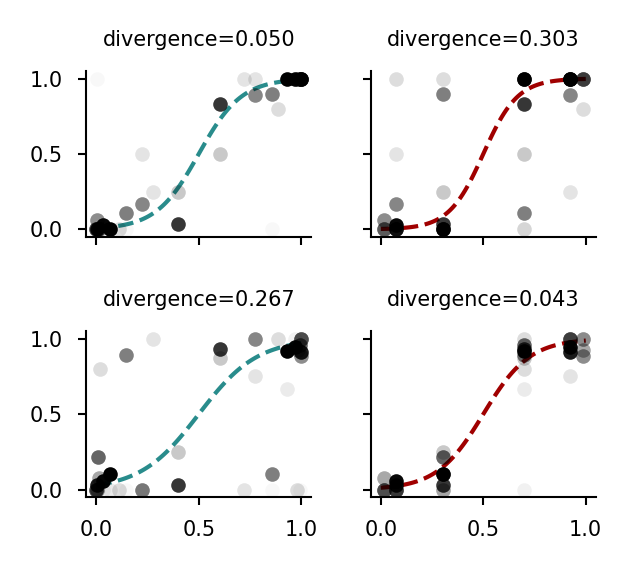

In [48]:
# psychometric functions for highlighted subjects, compared to IB-predicted psychometric functions for each bound (full and heuristic)

exp = 'highWS'
stats = 'highWS'

choicedf_ = pd.read_csv(horses_datadir + 'highWS/sj-psychometric-data.csv')
postdf_ = pd.read_csv(horses_datadir + 'highWS/strat-post-probs.csv')

ibdf_ = ibdf_dict[exp].copy()

fig, axs = plt.subplots(2,2, figsize=(2.25,2), dpi=300)

strats = ['fully-optimal','equal-weights']
strat_colors = {
    'fully-optimal': optcolor,
    'equal-weights': heurcolor
}
strat_bounds = {
    'fully-optimal': softmax_dict_horses[stats]['full'],
    'equal-weights': softmax_dict_horses[stats]['equal-weights']
}
conds1 = (choicedf_['subject_index'].notna())
conds2 = (ibdf_['subject_index'].notna())

for ii, sj in enumerate(highlighted_sjs):
    sjconds1 = conds1 & (choicedf_['subject_index'] == sj)
    sjconds2 = conds2 & (ibdf_['subject_index'] == sj)
    for jj, strat in enumerate(strats):
        utils.get_IB_predicted_psychometric_plot(ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat],strat_colors[strat],axs[ii,jj])
        utils.get_sj_psychometric_plot(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat], axs[ii,jj])
        dkl = utils.get_psychometric_DKL(choicedf_.loc[sjconds1], postdf_.loc[postdf_['strategy']==strat],ibdf_.loc[sjconds2,'Ixr'].values[0],strat_bounds[strat])
        format_axis(axs[ii,jj])
        axs[ii,jj].set_title(f'divergence={dkl:.3f}', fontsize=5)
        if ii == 0:
            axs[ii,jj].set_xticklabels([])
        if jj == 1:
            axs[ii,jj].set_yticklabels([])
plt.tight_layout()

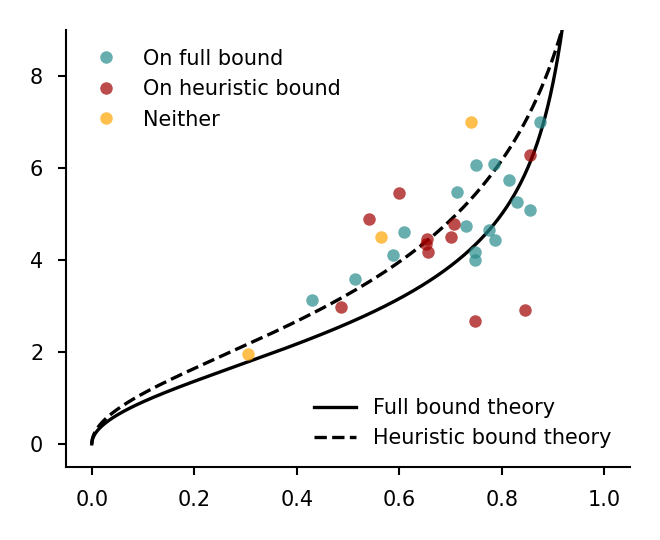

In [49]:
# plot choice noise term (best-fitting model betastar) vs I(X;R)
# EXCLUDE those with I(X;R) < 0.05

modeldf_ = pd.read_csv(horses_datadir + 'highWS/model_fits.csv')
alldata_ = pd.merge(ibdf_, modeldf_, on=['subject_ID', 'subject_index'])

exp = 'highWS'
stats = 'highWS'

conds = (alldata_['exclude_Ixr'] == 0)

fig, ax = plt.subplots(figsize=(2.3, 1.9), dpi=300)

ib_theory, = ax.plot(softmax_dict_horses[stats]['full']['I_XR'], softmax_dict_horses[stats]['full']['betastar'], 'k', alpha=1,linewidth=0.8,label='Full bound theory')
heur_theory, = ax.plot(softmax_dict_horses[stats]['equal-weights']['I_XR'], softmax_dict_horses[stats]['equal-weights']['betastar'], '--k', alpha=1,linewidth=0.8,label='Heuristic bound theory')

for sjind in pd.unique(alldata_.loc[conds,'subject_index']):
    sjconds = conds & (alldata_['subject_index'] == sjind)
    if (alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'full'):
        onfullbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=optcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On full bound')
    elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'equal-weights':
        onheurbound, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=heurcolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='On heuristic bound')
    elif alldata_.loc[conds & (alldata_['subject_index'] == sjind),'bound_class'].to_numpy() == 'none':
        other, = ax.plot(alldata_.loc[sjconds,'Ixr'],alldata_.loc[sjconds,'best_model_betastar'],'o',c=nonecolor,alpha=0.7,markersize=3,markeredgewidth=0,markeredgecolor='none',label='Neither')
leg1 = ax.legend(handles=[onfullbound, onheurbound, other],fontsize=5, frameon=False, loc='upper left')
leg2 = ax.legend(handles=[ib_theory, heur_theory],fontsize=5, frameon=False, loc='lower right')
ax.add_artist(leg1)
ax.set_ylim(-0.5,9)
format_axis(ax)
plt.tight_layout()

## Figure 5